# P01 (basic) — how the brain merges two senses: inverse-variance fusion

**Module 18 — Multimodal Interfaces**

In this project you recompute the **heart of multimodal fusion** yourself: the
**inverse-variance weighting** (maximum likelihood integration). It answers the question:
*if two modalities (e.g. seeing and touching) estimate the same value with noise — what is the
best joint estimate?*

This is at the same time the direct continuation of the **complementary filter from module 17**
(gyro + accel): the same formula, different senses. And it is the mathematics behind the famous
experiment by **Ernst & Banks (2002)**, which showed that the human brain fuses *exactly* this
way.

### Goal
After this project you can …
- derive inverse-variance fusion from the log likelihood and implement it in code,
- show that the fusion is **always more precise** than either individual modality
  ($\sigma_{fus}^2 \le \min$),
- reproduce the **reliability-based perceptual shift** under a sensory conflict
  (the central Ernst-Banks prediction),
- measure the **gain in discrimination** (a smaller JND).

### Format
A Jupyter notebook — ideal, because we see the formula, the simulation, the numbers and the plots
right next to each other.

### Prior knowledge
The Gaussian distribution, variance, a little probability theory. Chapters 8-9 of the module 18
script.

### Tasks
Most cells are given. At the places marked with `# TODO` **you** fill in the
core formulas. **This is the complete solution.**


## Setup

We need only `numpy` and `matplotlib`. Both are present in the repo `.venv`.
A fixed seed makes all random numbers reproducible.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)  # reproducibility
N = 40000                        # the number of simulated percepts


## Part A — merging two noisy sensors optimally

An object has the true edge height `s_true = 55.0` mm. Two modalities estimate it independently
and with noise (Gaussian):

$$\hat{s}_V \sim \mathcal{N}(s, \sigma_V^2), \qquad \hat{s}_H \sim \mathcal{N}(s, \sigma_H^2)$$

**Seeing** is more precise here ($\sigma_V = 1$ mm) than **touching** ($\sigma_H = 2$ mm).

The **reliability** of a modality is the inverse variance $r = 1/\sigma^2$. The optimal
(maximum likelihood) fusion weights **proportionally to the reliability**:

$$\hat{s} = w_V\,\hat{s}_V + w_H\,\hat{s}_H, \qquad
  w_V = \frac{1/\sigma_V^2}{1/\sigma_V^2 + 1/\sigma_H^2}, \quad
  w_H = \frac{1/\sigma_H^2}{1/\sigma_V^2 + 1/\sigma_H^2}$$

and the fusion is **more precise than either individual modality**:

$$\frac{1}{\sigma_{fus}^2} = \frac{1}{\sigma_V^2} + \frac{1}{\sigma_H^2}
  \;\Longrightarrow\; \sigma_{fus}^2 \le \min(\sigma_V^2, \sigma_H^2).$$

**Your task:** fill in the weights, the fused estimate and $\sigma_{fus}$.


In [2]:
s_true  = 55.0   # the true edge height in mm
sigma_V = 1.0    # seeing: more precise
sigma_H = 2.0    # touching: less precise

# Simulate N independent noisy measurements per modality
vis = rng.normal(s_true, sigma_V, N)
hap = rng.normal(s_true, sigma_H, N)

# reliabilities (inverse variances)
r_V = 1.0 / sigma_V**2
r_H = 1.0 / sigma_H**2

# the inverse-variance weights (they add up to 1)
w_V = r_V / (r_V + r_H)
w_H = r_H / (r_V + r_H)

# the fused estimate (element-wise, per percept)
fused = w_V * vis + w_H * hap

# the predicted fusion standard deviation sigma_fus
sigma_fus_pred = np.sqrt(1.0 / (r_V + r_H))

print(f"Weights:   w_V = {w_V:.3f},  w_H = {w_H:.3f}  (sum {w_V+w_H:.3f})")
print(f"empirical: std(vis)={vis.std():.3f}  std(hap)={hap.std():.3f}  std(fused)={fused.std():.3f}")
print(f"predicted: sigma_fus = {sigma_fus_pred:.3f}")
print(f"Is the fusion more precise than the better sensor? {fused.std() < min(sigma_V, sigma_H)}")


Weights:   w_V = 0.800,  w_H = 0.200  (sum 1.000)
empirical: std(vis)=1.005  std(hap)=2.002  std(fused)=0.895
predicted: sigma_fus = 0.894
Is the fusion more precise than the better sensor? True


**Expectation / self-check.** With $\sigma_V=1$, $\sigma_H=2$:
- $r_V = 1$, $r_H = 0.25$ → $w_V = 0.8$, $w_H = 0.2$ (the more precise seeing gets 80 % of the
  weight).
- $\sigma_{fus} = \sqrt{1/1.25} = \sqrt{0.8} \approx 0.894$ mm — **smaller than 1 mm**, so more
  precise than *either* individual sensor.
- The empirical `std(fused)` should hit 0.894 almost exactly.

The plot shows the three distributions: the fusion (green) is the narrowest.


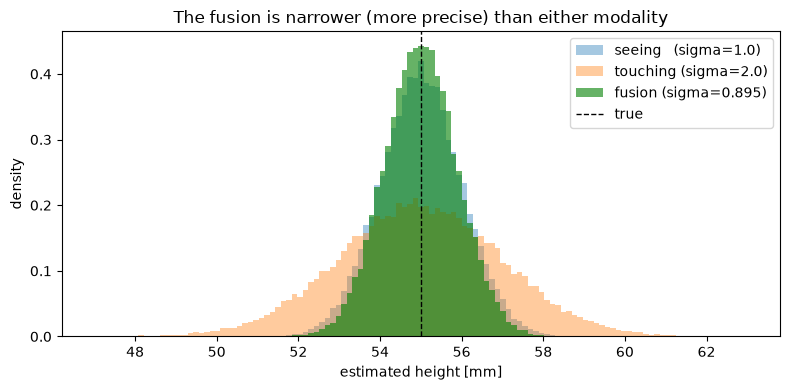

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(s_true - 8, s_true + 8, 120)
ax.hist(vis,   bins=bins, alpha=0.4, density=True, label=f"seeing   (sigma={sigma_V})")
ax.hist(hap,   bins=bins, alpha=0.4, density=True, label=f"touching (sigma={sigma_H})")
ax.hist(fused, bins=bins, alpha=0.6, density=True, color="green",
        label=f"fusion (sigma={fused.std():.3f})")
ax.axvline(s_true, color="k", ls="--", lw=1, label="true")
ax.set_xlabel("estimated height [mm]"); ax.set_ylabel("density")
ax.set_title("The fusion is narrower (more precise) than either modality")
ax.legend(); fig.tight_layout(); plt.show()


## Part B — the Ernst-Banks core: the perceptual shift under a sensory conflict

Now the actual experiment. Ernst & Banks (2002) secretly built in a **conflict**: what was seen
and what was touched said *different* values. Their prediction: the perceived value lies at the
**reliability-weighted mean** of the two — and moves towards the *more reliable* modality if you
make the other one noisy.

We simulate that: seeing is centred on `s_V`, touching on `s_H` (a conflict of 4 mm). The
"perceived" value is the mean of the fused estimate.

**Your task:** compute the *predicted* perceptual value `percept_pred` from the inverse-variance
weights (the same formula as in part A, applied to the centres `s_V`, `s_H`).


In [4]:
s_V, s_H = 53.0, 57.0   # the conflict: seeing says 53, touching says 57

def perceived(sigma_V, sigma_H, n=N):
    r_V, r_H = 1/sigma_V**2, 1/sigma_H**2
    wV, wH = r_V/(r_V+r_H), r_H/(r_V+r_H)
    v = rng.normal(s_V, sigma_V, n)
    h = rng.normal(s_H, sigma_H, n)
    fused = wV*v + wH*h
    percept_pred = wV*s_V + wH*s_H
    return fused.mean(), percept_pred, wV

# case 1: sharp seeing (sigma_V=1) -> the percept is close to seeing (53)
m1, p1, wv1 = perceived(1.0, 2.0)
# case 2: noisy seeing (sigma_V=4) -> the weight moves to touching -> the percept is close to 57
m2, p2, wv2 = perceived(4.0, 2.0)

print(f"sharp seeing: w_V={wv1:.2f} -> percept {m1:.2f} mm (predicted {p1:.2f})")
print(f"noisy seeing: w_V={wv2:.2f} -> percept {m2:.2f} mm (predicted {p2:.2f})")
print(f"=> The perceived value moved from {m1:.1f} to {m2:.1f} mm, although the")
print(f"   conflict (53 vs 57) did NOT change - only the reliability of the seeing.")


sharp seeing: w_V=0.80 -> percept 53.79 mm (predicted 53.80)
noisy seeing: w_V=0.20 -> percept 56.21 mm (predicted 56.20)
=> The perceived value moved from 53.8 to 56.2 mm, although the
   conflict (53 vs 57) did NOT change - only the reliability of the seeing.


**Expectation / self-check.**
- Case 1 (sharp seeing, $w_V=0.8$): the percept $= 0.8\cdot53 + 0.2\cdot57 = \mathbf{53.8}$ mm —
  close to **seeing**.
- Case 2 (noisy seeing $\sigma_V=4$, now $w_V=0.2$): the percept
  $= 0.2\cdot53 + 0.8\cdot57 = \mathbf{56.2}$ mm — close to **touching**.

**That is the core statement of Ernst & Banks:** the same physical conflict is perceived
*differently* depending on which modality is currently more reliable. The brain is an **adaptive
inverse-variance fuser** — and a multimodal interface should serve this expectation (consistent,
calibrated signals), otherwise a sensory conflict arises like the one behind the cybersickness
from module 17.

The following plot shows how the visual weight $w_V$ (and with it the percept) tips continuously
towards the haptics as the visual noise increases.


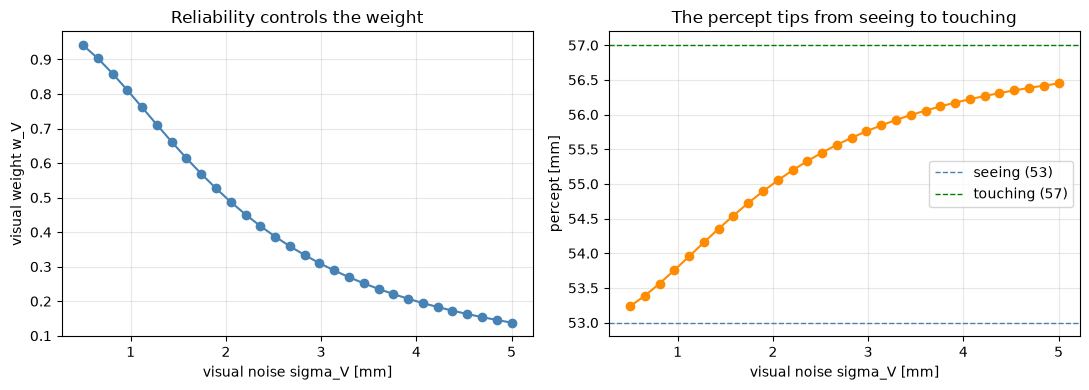

In [5]:
sig_V_range = np.linspace(0.5, 5.0, 30)
wv_curve = [1/sv**2 / (1/sv**2 + 1/2.0**2) for sv in sig_V_range]
percept_curve = [wv*s_V + (1-wv)*s_H for wv in wv_curve]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(sig_V_range, wv_curve, "o-", color="steelblue")
ax1.set_xlabel("visual noise sigma_V [mm]"); ax1.set_ylabel("visual weight w_V")
ax1.set_title("Reliability controls the weight"); ax1.grid(alpha=0.3)
ax2.plot(sig_V_range, percept_curve, "o-", color="darkorange")
ax2.axhline(s_V, color="steelblue", ls="--", lw=1, label="seeing (53)")
ax2.axhline(s_H, color="green", ls="--", lw=1, label="touching (57)")
ax2.set_xlabel("visual noise sigma_V [mm]"); ax2.set_ylabel("percept [mm]")
ax2.set_title("The percept tips from seeing to touching"); ax2.legend(); ax2.grid(alpha=0.3)
fig.tight_layout(); plt.show()


## Part C — the gain in discrimination (a smaller JND)

The third Ernst-Banks finding: the **discrimination threshold** (just-noticeable difference, JND)
drops through fusion. We test that with a **two-alternative forced choice task (2AFC)**: the
observer sees/touches two heights $s$ and $s+\Delta$ and picks the *larger* one — based on their
*noisy* estimate. With noise $\sigma$ the hit probability is theoretically

$$P(\text{correct}) = \Phi\!\left(\frac{\Delta}{\sigma\sqrt{2}}\right),$$

because the difference of two independent $\mathcal{N}(0,\sigma^2)$ errors has a spread of
$\sigma\sqrt2$. Because $\sigma_{fus}$ is the smallest, $P(\text{correct})$ is the highest for the
fusion — at the *same* $\Delta$ the fusion discriminates most reliably.

The cell is given; execute it and interpret it.


In [6]:
from math import erf, sqrt
def p_correct(delta, sigma):
    # P(correct) in a 2AFC = Phi(delta / (sigma*sqrt(2)))
    z = delta / (sigma * sqrt(2.0))
    return 0.5 * (1 + erf(z / sqrt(2.0)))

delta = 1.0  # the height difference to be discriminated, in mm
for name, sig in [("seeing", sigma_V), ("touching", sigma_H), ("fusion", sigma_fus_pred)]:
    print(f"{name:8s} (sigma={sig:.3f}): P(correct) at delta={delta} mm = {p_correct(delta, sig):.3f}")

# JND = the threshold at which P(correct)=0.75 (the 75 % point). Solve Phi(JND/(sigma*sqrt2))=0.75
from scipy.stats import norm
z75 = norm.ppf(0.75)
print()
for name, sig in [("seeing", sigma_V), ("touching", sigma_H), ("fusion", sigma_fus_pred)]:
    jnd = z75 * sig * sqrt(2.0)
    print(f"{name:8s}: JND (the 75 % threshold) = {jnd:.3f} mm")


seeing   (sigma=1.000): P(correct) at delta=1.0 mm = 0.760
touching (sigma=2.000): P(correct) at delta=1.0 mm = 0.638
fusion   (sigma=0.894): P(correct) at delta=1.0 mm = 0.785



seeing  : JND (the 75 % threshold) = 0.954 mm
touching: JND (the 75 % threshold) = 1.908 mm
fusion  : JND (the 75 % threshold) = 0.853 mm


**Expectation / self-check.** The fusion has the smallest $\sigma$ ($\approx 0.894$), hence the
highest $P(\text{correct})$ and the **smallest JND** — it discriminates more finely than seeing
(already the best individual modality) alone. That is *redundancy gain* quantified: two senses
together see more sharply than the sharper one alone.


## Part D — the arc back to module 17

A reminder of the **complementary filter** from module 17:
$$\theta = \alpha\,\theta_{\text{gyro}} + (1-\alpha)\,\theta_{\text{accel}}.$$
That is **the same** weighted fusion as here — only there $\alpha$ was chosen *heuristically*.
The **optimal** choice is the inverse-variance weighting:
$$\alpha^\star = \frac{1/\sigma_{\text{gyro}}^2}{1/\sigma_{\text{gyro}}^2 + 1/\sigma_{\text{accel}}^2} = w_V.$$

Sensor fusion (module 17) and multisensory perception (this module) are **the same mathematics** —
once in an IMU chip, once in the brain.

### Conclusion
You have reproduced the three Ernst-Banks findings:
1. **A gain in precision**: $\sigma_{fus} \le \min(\sigma_V, \sigma_H)$ (part A).
2. **A reliability-adaptive perceptual shift** under a conflict (part B) — the actual punchline.
3. **A smaller JND / redundancy gain** (part C).

With that you have the mathematical foundation on which the next two projects build:
*late-vs-early fusion & mutual disambiguation* (medium) and the *"Put-that-there" reference
resolution* (final).
